# Problem set 1: Printing and plotting - comments/solution

### Programming for Economists Autumn 2025: Classes 5 & 9
**Matias BF Hall**

**Learning goals**:

- Printing to screen, `print`
- Write to and read from text files, `.write` and `.read`
- Plot 2D figures using `.plot` in  `matplotlib`
- Plot 3D figures using `.plot_surface` in `matplotlib` with `np.meshgrid` and `projection='3d'`

**Problem set structure:** 

* Each problem set consists of tasks and problems. _Tasks_ train you in using specific techniques, while _problems_ train you in solving actual economic problems. 
* Each problem set also contains solutions, which can be found in separate Python files.
* The Python files `A*.py` do not always run out of the box. But you can copy the code into your notebook or user module. 
* *You should really try to solve the tasks and problems on your own before looking at the answers!* 
* Your goal should, however, not be to write everything from scratch. 
* Finding similar code from the lectures and adjusting it is completely ok.
* A quick peek at the solution, and then trying to write the solution yourself is also a very beneficial approach.

**Multiple solutions:** Within the field of numerical analysis there is often many more than one way of solving a specific problem. So the solution provided is just one example. If you get the same result, but use another approach, that might be just as good (or even better).

**Table of contents**<a id='toc0_'></a>    
- 1. [Define function](#toc1_)    
- 2. [Print to screen (table)](#toc2_)    
- 3. [Write the output to `table_output.txt`](#toc3_)    
- 4. [Read `table_output.txt` and print content to screen](#toc4_)    
- 5. [2D plot indifference curves](#toc5_)    
- 6. [3D plot of utility function](#toc6_)    
- 7. [Consumer choice and the budget set](#toc7_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

Imports you will need:

In [1]:
# Here we import packages we will use in the notebook
# We import numpy for numerical operations and matplotlib for plotting
# We import as shortened names to make it easier to call functions from these packages e.g. np.array instead of numpy.array
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D # for 3D plots
from matplotlib import cm # for colormap

# predefine options for all plots
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'-'})
plt.rcParams.update({'font.size': 14})

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

## 1. <a id='toc1_'></a>[Define function](#toc0_)

Implement a Python version of this function:

$$ 
u(x_1,x_2) = (\alpha x_1^{-\beta} + (1-\alpha) x_2^{-\beta})^{-1/\beta} 
$$

where $\beta > 0$.

where `x1` and `x2` are *positional arguments*, and `alpha`and `beta` are *keyword arguments* with default arguments $\alpha=0.5$ and $\beta=1$.

In [2]:
# under 'def' we define the name of the function and the arguments it takes
# after 'return' we tell what calling the function will return
def utility(x1,x2,alpha=0.5,beta=1):
    return (alpha*x1**(-beta) + (1-alpha)*x2**(-beta))**(-1/beta)

# x1 and x2 are positional arguments and must be called in the correct order
# alpha and beta are keyword arguments and can be called in any order, and have default values
# e.g. utility(1,2,beta=2) or utility(1,2,alpha=0.3) or utility(1,2,alpha=0.3,beta=2)

## 2. <a id='toc2_'></a>[Print to screen (table)](#toc0_)

In [3]:
# defines two vectors as lists
x1_vec = [1.05,1.3,2.3,2.5,3.1]
x2_vec = [1.05,1.3,2.3,2.5,3.1]

Construct a Python function `gen_table(x1_vec,x2_vec,u_func)` to print values of `u(x1,x2)` in the table form shown below.

In [4]:
def gen_table(x1_vec,x2_vec,u_func):
    
    # a. empty text
    text = ''
    
    # b. top header
    text += f'{"":3s}'
    # formats the string to be 3 characters wide, and a string(3s) and adds it to text
    for j, x2 in enumerate(x2_vec):
    #enumerate iterates through x2_vec and gives both the index j and the value x2
       text += f'{j:6d}' 
         # formats the index j to be 6 characters wide, and an integer(6d) and adds it to text
    text += '\n' # line shift
    
    # c. body
    for i, x1 in enumerate(x1_vec):
        if i > 0: text+='\n'
        # adds a line shift for each iteration except the first as we already did above
        text += f'{i:6d}'
        # the row header
        # formats the index i to be 6 characters wide, and an integer(6d) and adds it to text
        for j, x2 in enumerate(x2_vec):
            text += f'{u_func(x1,x2):6.3f}'
            # formats the utility value to be 6 characters wide, with 3 decimals (6.3f) and adds it to text
            
    
    # d. print
    return text

table = gen_table(x1_vec,x2_vec,utility)
# call the function with the utility function as an argument. Use the name of your function
print(table)

        0     1     2     3     4
     0 1.050 1.162 1.442 1.479 1.569
     1 1.162 1.300 1.661 1.711 1.832
     2 1.442 1.661 2.300 2.396 2.641
     3 1.479 1.711 2.396 2.500 2.768
     4 1.569 1.832 2.641 2.768 3.100


### Extra
Do you see a slightly more elegant solution with the newline above. HINT(You can remove the "if i>0" statement by removing other code). See solution below. If you want one more challenge you can think about how we can create both the header and body in the same loop using if statements - this last solution will not be elegant, but is more of a logical puzzle for the ones who want to give it a go.

In [5]:
def gen_table(x1_vec,x2_vec,u_func):
    # a. empty text
    text = ''
    # b. top header
    text += f'{"":3s}'
    for j, x2 in enumerate(x2_vec):
       text += f'{j:6d}' 
    # c. body
    for i, x1 in enumerate(x1_vec):
        text+='\n'
        # adding the line shift here instead of outside the loop lets us remove the if statement
        text += f'{i:6d}'
        for j, x2 in enumerate(x2_vec):
            text += f'{utility(x1,x2):6.3f}'
    # d. print
    return text

table = gen_table(x1_vec,x2_vec,utility)
print(table)

        0     1     2     3     4
     0 1.050 1.162 1.442 1.479 1.569
     1 1.162 1.300 1.661 1.711 1.832
     2 1.442 1.661 2.300 2.396 2.641
     3 1.479 1.711 2.396 2.500 2.768
     4 1.569 1.832 2.641 2.768 3.100


## 3. <a id='toc3_'></a>[Write the output to `table_output.txt`](#toc0_)

In [6]:
with open('Output\\table_output.txt', 'w') as f: 
    # 'w' is for 'write' and the first part is the relative path to the file you want to write to. 
    # as f is arbitrary, you can use any name you like, but 'f' for 'file' is common
    # the 'with' statement automatically closes the file when done
    # I chose to save the file in an Output folder, so you may need to create that folder first if you do the same
    # Alternatively delete 'Output\\' to save the file in the current folder
    f.write(gen_table(x1_vec,x2_vec,utility))
    # write the output of gen_table to the file
    # the f object has a write method that takes a string as an argument and writes it to the file

# If the filename doesn't already exist, a new file will be created. If it does exist, it will be overwritten.

## 4. <a id='toc4_'></a>[Read `table_output.txt` and print content to screen](#toc0_)

In [7]:
with open('Output\\table_output.txt', 'r') as f: # 'r' is for 'read'
    print(f.read())
    # read the content of the file and print it

        0     1     2     3     4
     0 1.050 1.162 1.442 1.479 1.569
     1 1.162 1.300 1.661 1.711 1.832
     2 1.442 1.661 2.300 2.396 2.641
     3 1.479 1.711 2.396 2.500 2.768
     4 1.569 1.832 2.641 2.768 3.100


## 5. <a id='toc5_'></a>[2D plot indifference curves](#toc0_)

The formula for the indifference curves of $u(x_1,x_2)$ is:

$$
x_2(x_1, u) = \left( \frac{u^{-\beta} - \alpha x_1^{-\beta}}{1-\alpha} \right)^{-1/\beta}
$$

for 

$$
\log(x_1) > \log(u) + \log(\alpha)/\beta
$$

Produce a figure like the one below and save to disc.

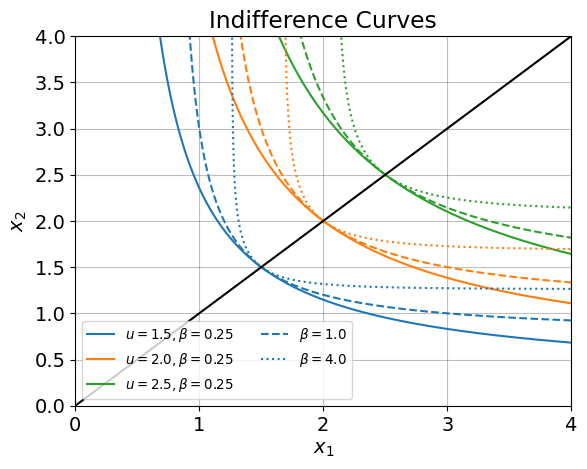

In [8]:
# these values were used
alpha = 0.5 
betas = [0.25, 1.0, 4.0]
uvals = [1.5, 2.0, 2.5]

# function to compute x2 given x1, u, alpha and beta
def x2_func(x1,u,alpha=0.5,beta=1):
    return ((u**(-beta)-alpha*x1**(-beta))/(1-alpha))**(-1/beta)


# Plotting

# Create figure and axis objects
fig = plt.figure()
# plt.figure is the figure object that contains all plot elements
ax = fig.add_subplot(1,1,1) # 1,1,1 is (nrows, ncols, index)
# add_subplot adds a subplot to the figure. Here we only have one subplot, but we could have more
# e.g. fig.add_subplot(2,2,1) would add a subplot in a 2x2 grid, in the first position

# Main loop to plot indifference curves
# We loop over the values of beta and uvals to plot the indifference curves
x1 = np.linspace(0.01,4.0,10000) # 10000 points from 0.01 to 4
for i,beta in enumerate(betas): # loop over values of beta
    for j,uval in enumerate(uvals): # loop over values of utility
        I = np.log(x1) > np.log(uval) + np.log(alpha)/beta
        # Create a boolean index array I where the condition is met
        # This ensures we only compute x2 where the expression inside the root is positive
        # This avoids complex numbers and NaNs in the plot
        # Try to print I to see what it looks like (Hint: Booleans are expressed with 1's and 0's)
        #print(I)
        
        x2 = x2_func(x1[I],uval,alpha,beta=beta)
        # we compute x2 for given values of x1, uval, alpha and beta
        # we use x1[I] to select only the values of x1 where the condition is met
        # it works because I is a boolean(true/false) array of the same length as x1 so every 
        # 'True' in I selects the corresponding value in x1 which are all the x1 values where the condition is met

        # Labeling - we set them so the graph is the same as Jeppe's
        if i == 0:
            label = f'$u={uval}, \\beta={beta}$'
        elif j == 0:
            label = f'$\\beta={beta}$'
        else:
            label = None
        
        ax.plot(x1[I],x2,label=label,color=colors[j],linestyle=['-','--',':'][i])
        # we plot the indifference curve with each iteration through uval and beta
        # label is used for the legend
        # color is chosen from the colors list set in the imports section in the top of the file, same utility has same colour
        # linestyle is chosen from a list of linestyles to match Jeppe's style, same beta has same linestyle


# Cosmetics

# 45 degree line
ax.plot([0,4],[0,4],color='black')
# we plot a line from (0,0) to (4,4) with color black
# can use zorder=0 to plot it first and bring it to the background

# Title and labels
ax.set_title('Indifference Curves')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

# Set axis limits and ticks
ax.set_xticks(np.arange(0,5,1))
# To replicate Jeppe's style, we set ticks at every integer from 0 to 4
ax.set_xlim(0.0,4.)
ax.set_ylim(0.0,4.)
# we set the x and y axis limits to be from 0 to 4

# Legend
ax.legend(ncols=2,prop={'size': 'x-small'})
# we add a legend with 2 columns and small font size

# Save figure
fig.savefig('Output\\2d_indifference_curves.png')
# Save the figure as a PNG file with the given filename in the current directory
# You can change the location by providing a path, e.g. 'figures/indifference_curves.png'
# Use either / or \\ in the path, not \ alone


***COMMENT***

Mine and Jeppes Code has slight differences. It is a good exercise to look at the differences, and explain to yourself, why, despite these differences the graphs are almost indistinguishable. You can also consider how, Jeppe's solution is contained in a function. Functions are good when you need to repeat a task - Here we only need to plot once so function/no function is the same.

**Hint:** To check your implementation of `x2(x1,u,alpha,beta)` you can use the code below.

In [9]:
x1_ = 2.0
x2_ = 1.5
# compute utility for given x1 and x2
u_ = utility(x1_,x2_,alpha=alpha,beta=betas[0])
# compute the implied x2 given x1 and utility
x2_implied = x2_func(x1_,u_,alpha=alpha,beta=betas[0])
# assert that x_ and x2_implied are close to each other, within a tolerance
# if they are not close, an AssertionError will be raised
assert np.isclose(x2_,x2_implied)

## 6. <a id='toc6_'></a>[3D plot of utility function](#toc0_)

**Task A:** Reproduce the figures below of $u(x_1,x_2)$ using:

1. the `meshgrid` function from *numpy* 
1. the `.plot_surface` and `.plot` axis methods from *matplotlib*.

where the black lines are indifference curves for $u \in \{1,2,3\}$.

**Hint:** Use the `zorder` argument so the black indifference curves are drawn *on top of* the surface (recall section 1.3 of the plotting lecture).

**Hint:** You can look at the documentation.

In [10]:
?np.meshgrid
# or
# help(np.meshgrid)
# I suggest also looking at ax.contour

Signature:       np.meshgrid(*xi, copy=True, sparse=False, indexing='xy')
Call signature:  np.meshgrid(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function meshgrid at 0x0000026A22EE96C0>
File:            c:\users\matia\anaconda3\lib\site-packages\numpy\lib\_function_base_impl.py
Docstring:      
Return a tuple of coordinate matrices from coordinate vectors.

Make N-D coordinate arrays for vectorized evaluations of
N-D scalar/vector fields over N-D grids, given
one-dimensional coordinate arrays x1, x2,..., xn.

Parameters
----------
x1, x2,..., xn : array_like
    1-D arrays representing the coordinates of a grid.
indexing : {'xy', 'ij'}, optional
    Cartesian ('xy', default) or matrix ('ij') indexing of output.
    See Notes for more details.
sparse : bool, optional
    If True the shape of the returned coordinate array for dimension *i*
    is reduced from ``(N1, ..., Ni, ... Nn)`` to
    ``(1, ..., 1, Ni, 1, ..., 1)``.  These sparse coordinate grids

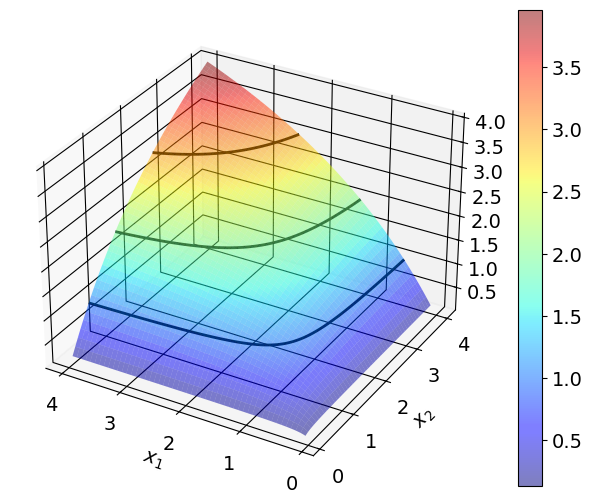

In [11]:
# these values were used
alpha = 0.50
beta = 1.0
x1_vec = np.linspace(0.1,4,1000)
x2_vec = np.linspace(0.1,4,1000)
uvals = [1.0,2.0,3.0]
# both x1_vec and x2_vec are numpy arrays with evenly spaced 1000 points from 0.1 to 4

# write your code here

x1_grid,x2_grid = np.meshgrid(x1_vec,x2_vec)
# creates a grid of x1 and x2 values for 3D plotting
# x1_grid and x2_grid are 2D arrays of shape (1000,1000) that is every combination of x1 and x2 values

u_grid = utility(x1_grid,x2_grid,alpha=alpha,beta=beta)
# compute utility for each combination of x1 and x2 in the grid



# create function for plotting indifference curves in 3D
def threeD_plot(x1_grid,x2_grid,u_grid):
    # Create figure and axis objects(in 3D) and plot surface
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1,projection='3d')
    h = ax.plot_surface(x1_grid,x2_grid,u_grid,cmap=cm.jet, alpha=0.5) # cmap is the colormap, alpha sets transparency
    # due to contour plot being below the surface, we set alpha to 0.5 to make the surface semi-transparent


    # Indifference curves using contour plot
    for uval in uvals:
        
        # create a mask to only plot where the condition is met
        I = np.log(x1_grid) > np.log(uval) + np.log(alpha)/beta
        u_grid_masked = np.where(I, u_grid, np.nan)
        
        # plot the contour
        ax.contour(x1_grid, x2_grid, u_grid_masked, levels=[uval], colors='black', linewidths=2)
        # we plot the contour where the utility is equal to uval
        # we use the masked grid to avoid plotting where the condition is not met

    # Cosmetics

    fig.colorbar(h) # adds a color bar to indicate the scale of utility values
    ax.invert_xaxis() # invert x axis to match Jeppe's style
    fig.tight_layout(pad=0.1) # adjusts the layout to fit everything in the figure area

    # labels

    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$');
    #; prevents printing the last line output
# plot using the function
threeD_plot(x1_grid,x2_grid,u_grid)

***COMMENT***

Check Jeppe's solution in A6 and make sure you understand the differences from mine

**Task B:** Repeat for $\beta = 2$.

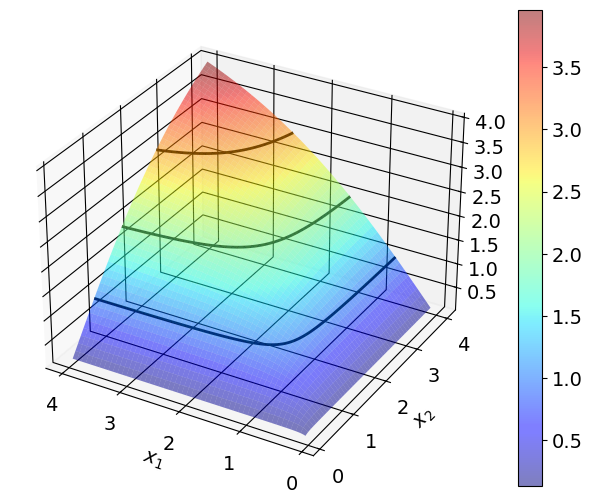

In [12]:
# write your code here

# compute a new utility grid with a different value of beta
beta_alt = 2.0
u_grid_alt = utility(x1_grid,x2_grid,alpha=alpha,beta=beta_alt)

# plot using the function
threeD_plot(x1_grid,x2_grid,u_grid_alt)

***COMMENT***

Notice how few lines of code we could produce another plot, due to the use of functions

## 7. <a id='toc7_'></a>[Consumer choice and the budget set](#toc0_)

A consumer with income $I$ faces prices $p_1$ and $p_2$. 

A bundle $(x_1,x_2)$ is **affordable** if

$$
p_1 x_1 + p_2 x_2 \leq I
$$

Produce a figure like the one below and save it to disc:

1. **Scatter** all affordable bundles, colored by their utility $u(x_1,x_2)$ from question 1, and add a `colorbar`.
1. Overlay the **budget line** $p_1 x_1 + p_2 x_2 = I$.
1. Mark the **utility-maximizing affordable bundle** (use `np.argmax`).

**Note:** Since *more is better*, the optimal bundle lies *on* the budget line.

optimal bundle: x1 = 2.9279, x2 = 4.1341 -> u = 3.4280


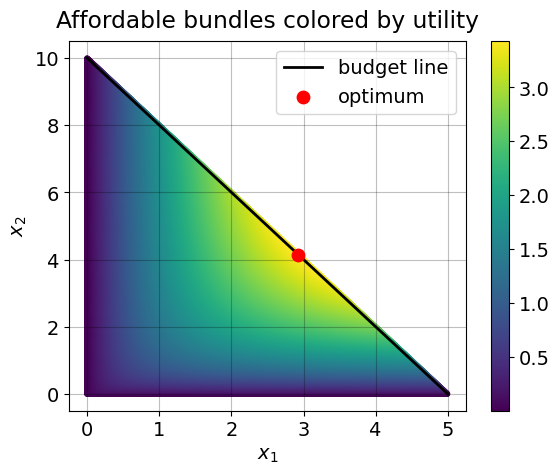

In [13]:
# these values were used
p1 = 2.0     # price of good 1
p2 = 1.0     # price of good 2
income = 10.0
alpha = 0.5
beta = 1.0

# write your code here

# create x1 and x2 vectors for the vec
x1_vec = np.linspace(1e-8, income/p1, 1000)
x2_vec = np.linspace(1e-8, income/p2, 1000) # evenly spaced vecs from a number close to zero to income/price, with 10000 points each

x1_grid, x2_grid = np.meshgrid(x1_vec, x2_vec) # create a grid of x1 and x2 values for computing utility at all possible combinations of x1 and x2

# create boolean to index with, only points that are feasible given the budget constraint will be True, all others will be False
I = (p1*x1_grid + p2*x2_grid) <= income

# compute utility for each combination of x1 and x2 in the vec, using I to only select feasible combinations
u_grid = utility(x1_grid[I], x2_grid[I], alpha=alpha, beta=beta) # this is still the same utility function defined in the beginning

# find the index of the maximum utility
ui_star = np.argmax(u_grid, keepdims=True)

# using the index find the maximum utility and the corresponding x1 and x2 values
u_star = u_grid[ui_star][0]
x1_star = x1_grid[I].flatten()[ui_star][0] # we both need to index the grids with feasible points and flatten the grid since the optimal index is an integer, that is one dimensional
x2_star = x2_grid[I].flatten()[ui_star][0] # we finally index to 0 to to get a float value instead of an array with one element

assert x1_star*p1 + x2_star*p2 <= income, "The optimal bundle exceeds the budget constraint"

# Plotting - to keep cosmetics the same it is just Jeppe's code but modified with my variable names

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# i. scatter of affordable bundles colored by utility
h = ax.scatter(x1_grid[I],x2_grid[I],s=10,c=u_grid) # s is the size of the marker, c is colour and passing an array like u_grid creates a colour map corresponding to the values
fig.colorbar(h)

# ii. budget line
ax.plot([0,income/p1],[income/p2,0],color='black',lw=2,label='budget line') # lw = line width

# iii. optimum
ax.scatter(x1_star,x2_star,color='red',s=80,zorder=5,label='optimum') #zorder sets the order of the plot elements, higher numbers are plotted on top of lower numbers

# labels
ax.set_title('Affordable bundles colored by utility',pad=10)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

ax.legend(loc='upper right')

fig.savefig('Output\\budgetset.png')

print(f'optimal bundle: x1 = {x1_star:.4f}, x2 = {x2_star:.4f} -> u = {u_star:.4f}')


***COMMENT***

argmax only finds solutions on the grid you created, why we get closer to the actual optimum as we increase gridpoints. But computation grows exponentially.